In [27]:
import torch
from model import SolarLSTM
from dataset import SolarLSTMDataset
import pandas as pd
import torch.nn as nn

In [20]:
df = pd.read_csv("final.csv")

In [21]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [43]:
def train_model(model, train_loader, val_loader, data,epochs=20, lr=0.001, device='cuda',offset = 0):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
        
        train_loss /= len(train_loader.dataset)

        val_loss = evaluate_model(model, val_loader, criterion, device)
        data[epoch+offset]=train_loss
        print(f"Epoch {epoch+1+offset}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

def evaluate_model(model, val_loader, criterion, device='cuda'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item() * X.size(0)
    return val_loss / len(val_loader.dataset)


In [38]:
from torch.utils.data import DataLoader, random_split
import pandas as pd
dataset = SolarLSTMDataset(df, seq_len=24)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Model
input_size = dataset.X.shape[2]
model = SolarLSTM(input_size=input_size)

# Train


In [55]:
dataset.X.shape

torch.Size([8760, 24, 14])

In [39]:
data ={}

In [47]:

train_model(model, train_loader, val_loader, epochs=100, lr=0.001,data=data,offset=len(data))


Epoch 401: Train Loss = 9.4133, Val Loss = 393.0312
Epoch 402: Train Loss = 9.6197, Val Loss = 403.7205
Epoch 403: Train Loss = 12.0213, Val Loss = 407.2308
Epoch 404: Train Loss = 10.9289, Val Loss = 393.1511
Epoch 405: Train Loss = 9.9487, Val Loss = 422.0456
Epoch 406: Train Loss = 12.8880, Val Loss = 405.9718
Epoch 407: Train Loss = 26.9235, Val Loss = 443.1276
Epoch 408: Train Loss = 17.3819, Val Loss = 408.3666
Epoch 409: Train Loss = 8.3948, Val Loss = 393.3552
Epoch 410: Train Loss = 5.3206, Val Loss = 389.4102
Epoch 411: Train Loss = 4.7177, Val Loss = 399.6517
Epoch 412: Train Loss = 4.4468, Val Loss = 395.6640
Epoch 413: Train Loss = 5.3223, Val Loss = 400.4569
Epoch 414: Train Loss = 4.3099, Val Loss = 391.6175
Epoch 415: Train Loss = 6.3460, Val Loss = 399.5662
Epoch 416: Train Loss = 9.4229, Val Loss = 416.8268
Epoch 417: Train Loss = 9.6806, Val Loss = 406.5879
Epoch 418: Train Loss = 9.3597, Val Loss = 419.1809
Epoch 419: Train Loss = 7.9309, Val Loss = 397.6819
Epoch 4

In [49]:
import matplotlib.pyplot as plt

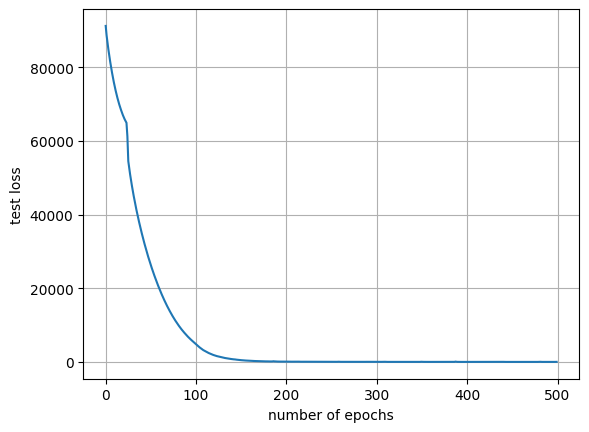

In [52]:
plt.plot(list(data.keys()),list(data.values()))
plt.xlabel("number of epochs")
plt.ylabel("test loss")
plt.grid(True)

In [53]:
torch.save(model.state_dict(),"models/version2.pth")

In [57]:
loss_fn = nn.MSELoss()

In [60]:
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to('cuda'), y.to('cuda')
        preds = model(X)
        print(preds[0])
        loss = loss_fn(preds, y)


tensor([171.0810], device='cuda:0')
tensor([755.2513], device='cuda:0')
tensor([0.0577], device='cuda:0')
tensor([-0.9592], device='cuda:0')
tensor([101.6121], device='cuda:0')
tensor([616.3111], device='cuda:0')
tensor([-0.9835], device='cuda:0')
tensor([366.2784], device='cuda:0')
tensor([-0.1612], device='cuda:0')
tensor([190.4381], device='cuda:0')
tensor([-0.9851], device='cuda:0')
tensor([-0.4384], device='cuda:0')
tensor([894.7984], device='cuda:0')
tensor([-0.3301], device='cuda:0')
tensor([-1.1211], device='cuda:0')
tensor([396.7848], device='cuda:0')
tensor([124.4957], device='cuda:0')
tensor([-0.5442], device='cuda:0')
tensor([-0.9899], device='cuda:0')
tensor([505.3874], device='cuda:0')
tensor([718.7461], device='cuda:0')
tensor([586.3856], device='cuda:0')
tensor([-0.3217], device='cuda:0')
tensor([286.5681], device='cuda:0')
tensor([18.1698], device='cuda:0')
tensor([24.6909], device='cuda:0')
tensor([-0.8661], device='cuda:0')
tensor([-0.0263], device='cuda:0')
